In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
df = pd.read_csv('./DataSet/trx-10k.csv')
df.dropna(inplace=True)
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 9578 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   status     9578 non-null   object
 1   time       9578 non-null   object
 2   card_type  9578 non-null   object
 3   city       9578 non-null   object
 4   amount     9578 non-null   int64 
 5   id         9578 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 523.8+ KB


,amount,id
count,9.578000e+03,9578.000000
mean,2.492398e+06,50.050324
std,1.442460e+06,28.917290
min,1.048100e+04,1.000000
25%,1.247962e+06,25.000000
50%,2.471254e+06,50.000000
75%,3.747052e+06,74.750000
max,4.997913e+06,100.000000


In [23]:
df.head()

,status,time,card_type,city,amount,id
0,success,2025-09-07 10:48:00,Visa,Tehran,470243,98
1,success,2025-09-20 13:10:00,MastCard,Tehran,4025070,52
2,fail,2025-09-29 03:27:00,Visa,Tehran,3573895,20
3,success,2025-09-15 13:13:00,Discover,Isfahan,4961173,40
4,success,2025-09-11 11:11:00,Visa,Tehran,2067746,59


In [24]:
# Lets Wash The Dirty Data :)
# Status Col

df['status'] = df['status'].str.lower().str.strip()
df['status'].unique()


array(['success', 'fail', 'failed', 'succeed'], dtype=object)

In [25]:
def status_cleaner(x:str):
    if x in ['success','succeed']:
        return 'success'
    
    elif x in ['fail','failed']:
        return 'fail'
    
    return np.nan

df['status'] = df['status'].apply(status_cleaner)

df['status'].dropna(inplace=True)
df['status'].unique()

array(['success', 'fail'], dtype=object)

In [26]:
# Time Col

df['time'] = pd.to_datetime(df['time'],errors='coerce',format='%Y-%m-%d %H:%M:%S')
df['time'].isnull().sum()

np.int64(0)

In [27]:
# Card Type Col

df['card_type'] = df['card_type'].str.lower().str.strip()
df['card_type'].unique()

array(['visa', 'mastcard', 'discover', 'master-card', 'amex',
       'mastercard', 'vsa', 'master card'], dtype=object)

In [28]:
def clean_CardType(x:str):
    if x in ['mastcard','master-card','mastercard','master card']:
        return "MasterCard"
    elif x in ['visa','vsa']:
        return "Visa"
    elif x == 'discover':
        return "Discover"
    elif x == 'amex':
        return 'Amex'
    
    return np.nan

df['card_type'] = df['card_type'].apply(clean_CardType)

df['card_type'].isnull().sum()


np.int64(0)

In [29]:
# City Col

df['city'] = df['city'].str.lower().str.strip()

df['city'].unique()

array(['tehran', 'isfahan', 'tabriz', 'shiraz', 'karaj', 'ahvaz', 'thr',
       'qom', 'mashhad', 'tehr@n', 'thran'], dtype=object)

In [30]:
def clean_city(x:str):
    if x in ['tehran','thr','tehr@n','thran']:
        return "Tehran"
    
    elif x in ['mashhad','qom','ahvaz','karaj','shiraz','tabriz','isfahan']:
        return x.capitalize()
    
    return np.nan

df['city'] = df['city'].apply(clean_city)
df['city'].isnull().sum()

np.int64(0)

In [31]:
df['city'].unique()

array(['Tehran', 'Isfahan', 'Tabriz', 'Shiraz', 'Karaj', 'Ahvaz', 'Qom',
       'Mashhad'], dtype=object)

In [32]:
# Id Col Moving

cols = ['id'] + [col for col in df.columns if col != 'id']
df = df.reindex(columns=cols)

df.head()

,id,status,time,card_type,city,amount
0,98,success,2025-09-07 10:48:00,Visa,Tehran,470243
1,52,success,2025-09-20 13:10:00,MasterCard,Tehran,4025070
2,20,fail,2025-09-29 03:27:00,Visa,Tehran,3573895
3,40,success,2025-09-15 13:13:00,Discover,Isfahan,4961173
4,59,success,2025-09-11 11:11:00,Visa,Tehran,2067746


In [33]:
df = df.sort_values(by='id')
df

,id,status,time,card_type,city,amount
9964,1,fail,2025-09-04 11:11:00,Visa,Isfahan,2042069
9990,1,fail,2025-09-23 09:45:00,Amex,Karaj,3720633
8965,1,fail,2025-09-19 14:55:00,Discover,Tehran,201320
2275,1,success,2025-09-09 07:08:00,MasterCard,Qom,4556108
5372,1,fail,2025-09-26 13:13:00,Discover,Isfahan,2854093
...,...,...,...,...,...,...
1065,100,fail,2025-09-28 03:00:00,MasterCard,Tehran,294175
3751,100,fail,2025-09-24 13:13:00,Amex,Mashhad,4035709
5310,100,success,2025-09-28 20:20:00,Amex,Mashhad,703002
5715,100,success,2025-09-29 13:13:00,MasterCard,Ahvaz,4245781


In [34]:
"Duplicated Transctions Percentage : " + str((df['id'].duplicated().sum() / len(df['id'])).round(2) * 100)

# So Its Not Outlier And Its Normal Because A Person Can Have Transactions More Than One

'Duplicated Transctions Percentage : 99.0'

In [35]:
df = df.reset_index(drop=True)
df.head()

,id,status,time,card_type,city,amount
0,1,fail,2025-09-04 11:11:00,Visa,Isfahan,2042069
1,1,fail,2025-09-23 09:45:00,Amex,Karaj,3720633
2,1,fail,2025-09-19 14:55:00,Discover,Tehran,201320
3,1,success,2025-09-09 07:08:00,MasterCard,Qom,4556108
4,1,fail,2025-09-26 13:13:00,Discover,Isfahan,2854093


In [36]:
df['amount'].describe()

count    9.578000e+03
mean     2.492398e+06
std      1.442460e+06
min      1.048100e+04
25%      1.247962e+06
50%      2.471254e+06
75%      3.747052e+06
max      4.997913e+06
Name: amount, dtype: float64

In [37]:
df['time'].describe()

count                             9578
mean     2025-09-16 05:08:47.546460416
min                2025-09-01 00:00:00
25%                2025-09-08 14:55:00
50%                2025-09-16 08:59:00
75%                2025-09-23 16:40:00
max                2025-09-30 23:59:00
Name: time, dtype: object

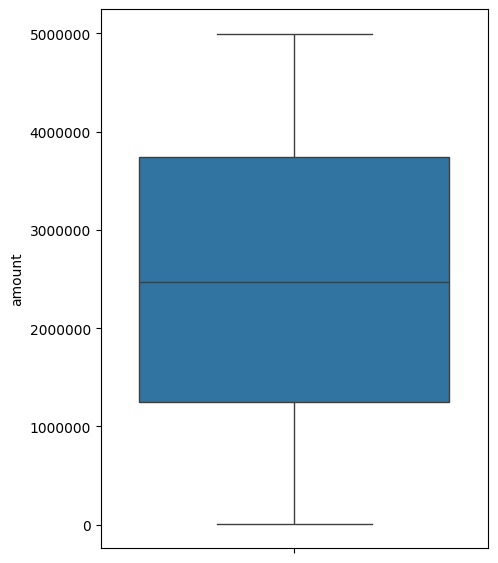

In [ ]:

plt.figure(figsize=(5,7))
sns.boxplot(df['amount'])
plt.ticklabel_format(style='plain', axis='y')


In [62]:
q1 = df['amount'].quantile(0.25)
q3 = df['amount'].quantile(0.75)

IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

df[(df['amount'] > upper_bound) | (df['amount'] < lower_bound)]

,id,status,time,card_type,city,amount,z_score


In [56]:
# By Z Score

mean = df['amount'].mean()
std = df['amount'].std()

df['z_score'] = (df['amount'] - mean) / std
df[df['z_score'] > 3]

,id,status,time,card_type,city,amount,z_score


In [ ]:
df.iloc[df['z_score'].idxmax()]

id                            62
status                      fail
time         2025-09-29 14:00:00
card_type               Discover
city                     Isfahan
amount                   4997913
z_score                 1.736974
Name: 5962, dtype: object